In [1]:
import zipfile
import os

zip_path = "/content/PRCP-1001-RiceLeaf.zip"
extract_path = "/content/rice_leaf_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['Data']


In [2]:
import os

for root, dirs, files in os.walk("/content/rice_leaf_dataset"):
    print("Folder:", root)
    print("Number of files:", len(files))
    print()

Folder: /content/rice_leaf_dataset
Number of files: 0

Folder: /content/rice_leaf_dataset/Data
Number of files: 3



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
dataset_path = "/content/rice_leaf_dataset"

print("Dataset path:", dataset_path)
print("Dataset folder exists:", os.path.exists(dataset_path))

Dataset path: /content/rice_leaf_dataset
Dataset folder exists: True


In [5]:
import os

dataset_path = "/content/rice_leaf_dataset"

for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):
        print("Class:", item)
        print("Number of images:", len(os.listdir(item_path)))
        print()

Class: Data
Number of images: 3



In [6]:
import os

dataset_path = "/content/rice_leaf_dataset"

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        image_count = len([file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))])

        class_counts[class_name] = image_count

print("Image count for each class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

Image count for each class:
Data: 0 images


In [7]:
class_distribution = pd.DataFrame(list(class_counts.items()),columns=["Class", "Number of Images"])
class_distribution

,Class,Number of Images
0,Data,0


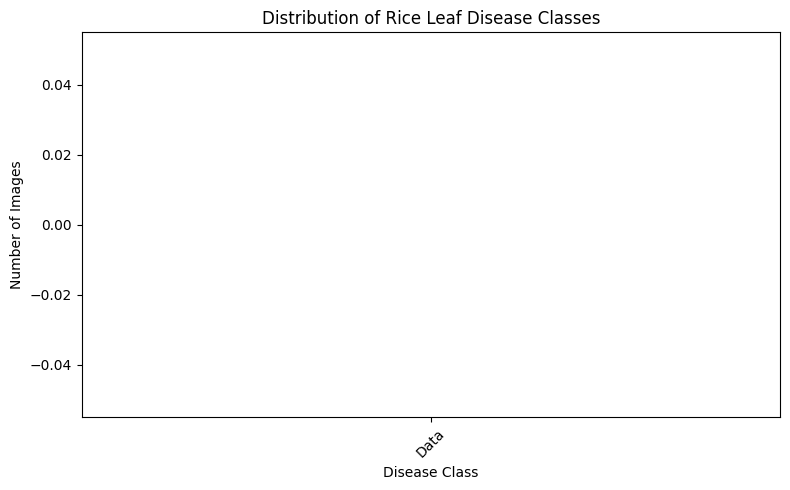

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(class_distribution["Class"],class_distribution["Number of Images"])

plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Rice Leaf Disease Classes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
import zipfile

zip_path = "/content/PRCP-1001-RiceLeaf.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    files = zip_ref.namelist()

print("Total files/folders in ZIP:", len(files))

for item in files[:30]:
    print(item)

Total files/folders in ZIP: 3
Data/Leaf smut-20200814T055530Z-001.zip
Data/Brown spot-20200814T055208Z-001.zip
Data/Bacterial leaf blight-20200814T055237Z-001.zip


In [10]:
import zipfile
import os

zip_path = "/content/PRCP-1001-RiceLeaf.zip"
extract_path = "/content/rice_leaf_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Extracted location:", extract_path)

Dataset extracted successfully!
Extracted location: /content/rice_leaf_dataset


In [11]:
import os

dataset_path = "/content/rice_leaf_dataset"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Number of files:", len(files))
    print()

Folder: /content/rice_leaf_dataset
Number of files: 0

Folder: /content/rice_leaf_dataset/Data
Number of files: 3



In [12]:
import os

dataset_path = "/content/rice_leaf_dataset"

print("Folders inside dataset:")

for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):
        print("-", item)

Folders inside dataset:
- Data


In [13]:
import os

dataset_path = "/content/rice_leaf_dataset"

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        image_files = [file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))]

        class_counts[class_name] = len(image_files)

print("Image count for each class:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

Image count for each class:
Data: 0 images


In [14]:
import zipfile
import os

outer_zip = "/content/PRCP-1001-RiceLeaf.zip"
dataset_path = "/content/rice_leaf_dataset"

# Extract the main ZIP
with zipfile.ZipFile(outer_zip, "r") as zip_ref:
    zip_ref.extractall(dataset_path)

# Extract the three disease ZIP files
data_path = os.path.join(dataset_path, "Data")

for zip_file in os.listdir(data_path):
    if zip_file.endswith(".zip"):

        zip_path = os.path.join(data_path, zip_file)

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(data_path)

print("All disease images extracted successfully!")
print(os.listdir(data_path))

All disease images extracted successfully!
['Leaf smut', 'Bacterial leaf blight-20200814T055237Z-001.zip', 'Brown spot-20200814T055208Z-001.zip', 'Bacterial leaf blight', 'Brown spot', 'Leaf smut-20200814T055530Z-001.zip']


Disease Classes:
- Leaf smut
- Bacterial leaf blight
- Brown spot


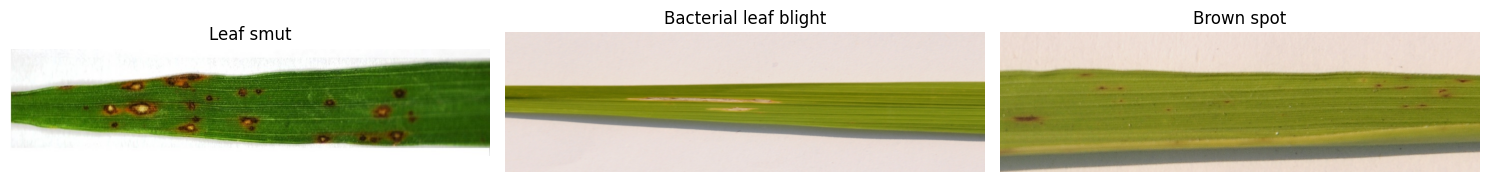

In [15]:
from PIL import Image
import os
import matplotlib.pyplot as plt

data_path = "/content/rice_leaf_dataset/Data"

classes = [folder for folder in os.listdir(data_path)
    if os.path.isdir(os.path.join(data_path, folder))]

print("Disease Classes:")
for class_name in classes:
    print("-", class_name)

plt.figure(figsize=(15, 5))

for i, class_name in enumerate(classes):
    class_path = os.path.join(data_path, class_name)

    image_files = []

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_files.append(os.path.join(root, file))

    if len(image_files) > 0:
        image = Image.open(image_files[0])

        plt.subplot(1, len(classes), i + 1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(data_path, class_name)

    image_count = 0

    for root, dirs, files in os.walk(class_path):
        image_count += len([file for file in files
            if file.lower().endswith((".jpg", ".jpeg", ".png"))])

    class_counts[class_name] = image_count

print("Image count for each class:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

Image count for each class:
Leaf smut: 39 images
Bacterial leaf blight: 40 images
Brown spot: 40 images


In [17]:
import pandas as pd

class_distribution = pd.DataFrame(list(class_counts.items()),columns=["Class", "Number of Images"])

print("Class Distribution:")
display(class_distribution)

Class Distribution:


,Class,Number of Images
0,Leaf smut,39
1,Bacterial leaf blight,40
2,Brown spot,40


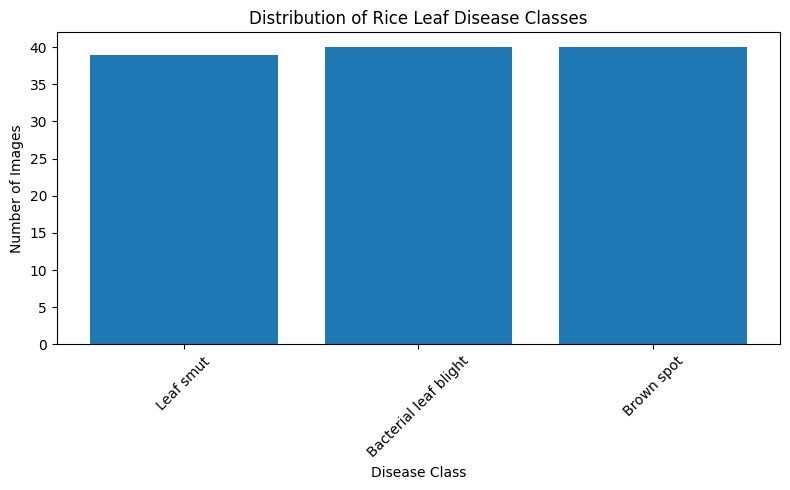

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(class_distribution["Class"],class_distribution["Number of Images"])

plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Rice Leaf Disease Classes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
image_data = []

for class_name in classes:
    class_path = os.path.join(data_path, class_name)

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_path = os.path.join(root, file)

                image_data.append({"Image_Path": image_path,"Class": class_name})

image_df = pd.DataFrame(image_data)

print("Total images:", len(image_df))
display(image_df.head())

Total images: 119


,Image_Path,Class
0,/content/rice_leaf_dataset/Data/Leaf smut/DSC_...,Leaf smut
1,/content/rice_leaf_dataset/Data/Leaf smut/DSC_...,Leaf smut
2,/content/rice_leaf_dataset/Data/Leaf smut/DSC_...,Leaf smut
3,/content/rice_leaf_dataset/Data/Leaf smut/DSC_...,Leaf smut
4,/content/rice_leaf_dataset/Data/Leaf smut/DSC_...,Leaf smut


In [20]:
print("Unique Classes:")
print(image_df["Class"].unique())

print("\nNumber of images in each class:")
print(image_df["Class"].value_counts())

Unique Classes:
['Leaf smut' 'Bacterial leaf blight' 'Brown spot']

Number of images in each class:
Class
Bacterial leaf blight    40
Brown spot               40
Leaf smut                39
Name: count, dtype: int64


In [21]:
from PIL import Image

IMG_SIZE = 128

image = Image.open(image_df["Image_Path"].iloc[0])

print("Original image size:", image.size)

resized_image = image.resize((IMG_SIZE, IMG_SIZE))

print("Resized image size:", resized_image.size)

Original image size: (948, 211)
Resized image size: (128, 128)


In [22]:
import numpy as np

X = []
y = []

for _, row in image_df.iterrows():
    image = Image.open(row["Image_Path"]).convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    X.append(np.array(image))
    y.append(row["Class"])

X = np.array(X)
y = np.array(y)

print("Image data shape:", X.shape)
print("Label data shape:", y.shape)

Image data shape: (119, 128, 128, 3)
Label data shape: (119,)


In [23]:
X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())
print("Image data shape:", X.shape)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Image data shape: (119, 128, 128, 3)


In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original Classes:")
print(label_encoder.classes_)

print("\nEncoded Labels:")
print(np.unique(y_encoded))

Original Classes:
['Bacterial leaf blight' 'Brown spot' 'Leaf smut']

Encoded Labels:
[0 1 2]


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.20,random_state=42,stratify=y_encoded)

print("Training images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])
print("Training labels:", y_train.shape[0])
print("Testing labels:", y_test.shape[0])

Training images: 95
Testing images: 24
Training labels: 95
Testing labels: 24


In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (95, 128, 128, 3)
X_test shape: (24, 128, 128, 3)
y_train shape: (95,)
y_test shape: (24,)


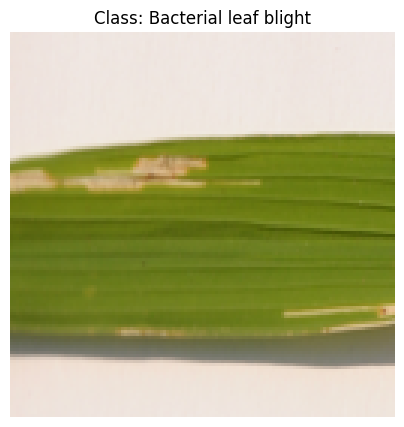

In [27]:
plt.figure(figsize=(5, 5))

plt.imshow(X_train[0])
plt.title("Class: " + label_encoder.inverse_transform([y_train[0]])[0])

plt.axis("off")
plt.show()

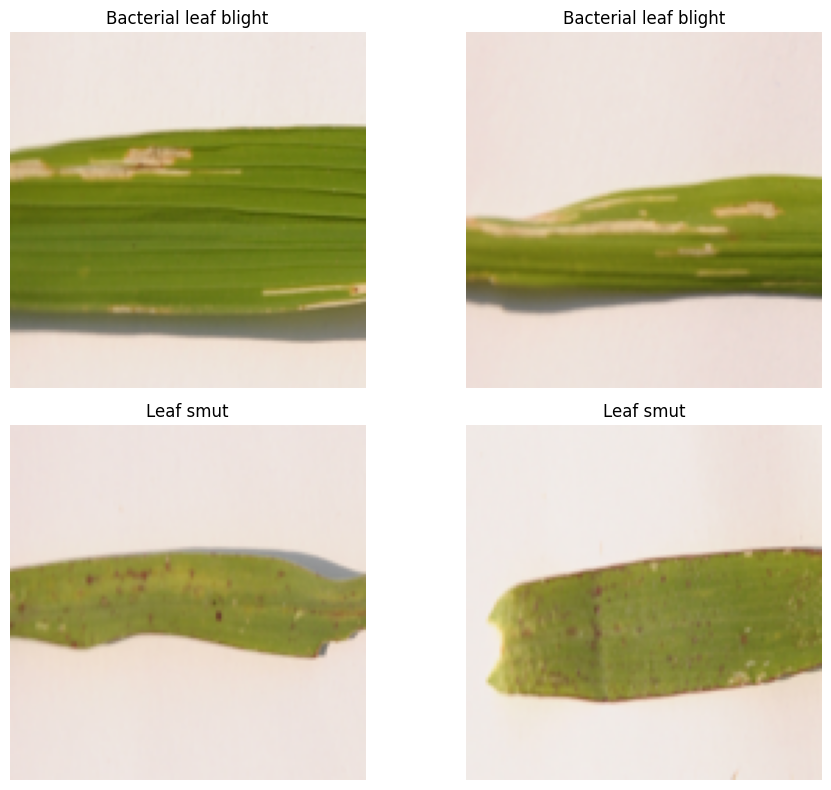

In [28]:
plt.figure(figsize=(10, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    plt.imshow(X_train[i])

    class_name = label_encoder.inverse_transform([y_train[i]])[0]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = len(label_encoder.classes_)

model = Sequential([Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
print("CNN model compiled successfully!")

CNN model compiled successfully!


In [31]:
history = model.fit(X_train,y_train,validation_data=(X_test, y_test),epochs=10,batch_size=32)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2947 - loss: 1.2743 - val_accuracy: 0.3333 - val_loss: 1.1043
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 961ms/step - accuracy: 0.2632 - loss: 1.1147 - val_accuracy: 0.3333 - val_loss: 1.0826
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 856ms/step - accuracy: 0.4105 - loss: 1.0776 - val_accuracy: 0.3333 - val_loss: 1.0576
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 999ms/step - accuracy: 0.4105 - loss: 1.0321 - val_accuracy: 0.5000 - val_loss: 1.0243
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 880ms/step - accuracy: 0.4737 - loss: 1.0210 - val_accuracy: 0.5833 - val_loss: 0.9583
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 973ms/step - accuracy: 0.4947 - loss: 0.9665 - val_accuracy: 0.6667 - val_loss: 0.9123
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 882ms/step - accuracy: 0.4737 - loss: 0.9922 - val_accuracy: 0.6250 - val_loss: 0.8672
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 939ms/step - accuracy: 0.5789 - loss: 0.8675 - val_accuracy: 0.6250 - val_loss: 0.

In [32]:
test_loss, test_accuracy = model.evaluate(X_test,y_test,verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6667 - loss: 0.6213
Test Loss: 0.6212787628173828
Test Accuracy: 0.6666666865348816


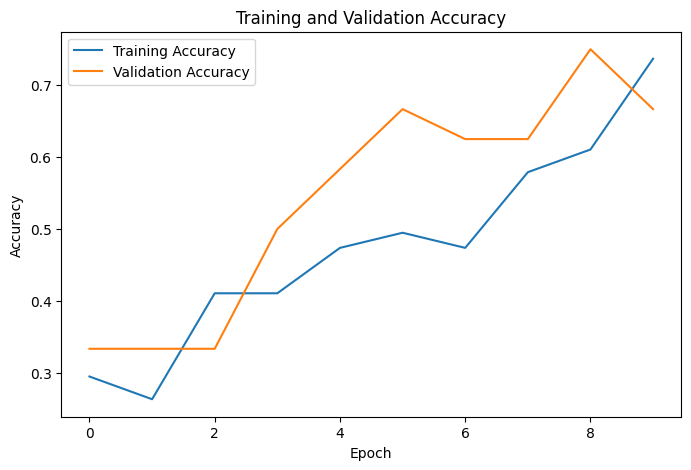

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

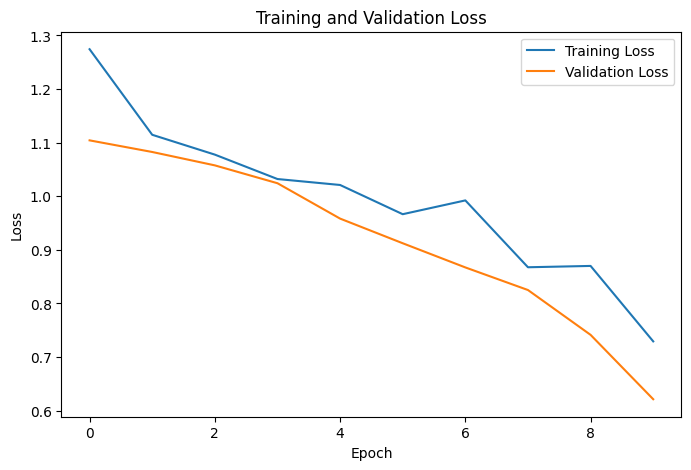

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [35]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted labels:")
print(y_pred)

print("\nActual labels:")
print(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Predicted labels:
[2 0 2 1 0 0 0 0 0 0 1 1 0 1 1 2 0 0 0 0 1 1 0 1]

Actual labels:
[2 1 2 1 0 2 0 2 0 1 1 1 0 2 1 2 0 0 2 2 1 0 0 1]


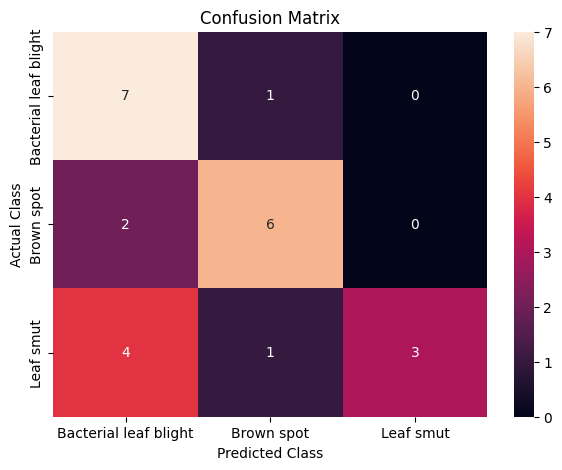

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(cm,annot=True,fmt="d",xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

In [37]:
from sklearn.metrics import classification_report

report = classification_report(y_test,y_pred,target_names=label_encoder.classes_)

print(report)

                       precision    recall  f1-score   support

Bacterial leaf blight       0.54      0.88      0.67         8
           Brown spot       0.75      0.75      0.75         8
            Leaf smut       1.00      0.38      0.55         8

             accuracy                           0.67        24
            macro avg       0.76      0.67      0.65        24
         weighted avg       0.76      0.67      0.65        24



In [38]:
model.save("/content/rice_leaf_disease_cnn.h5")

print("CNN model saved successfully!")

CNN model saved successfully!


In [39]:
import joblib

joblib.dump(label_encoder,"/content/rice_leaf_label_encoder.pkl")

print("Label encoder saved successfully!")

Label encoder saved successfully!


In [40]:
from tensorflow.keras.models import load_model
import joblib

loaded_model = load_model("/content/rice_leaf_disease_cnn.h5")
loaded_label_encoder = joblib.load("/content/rice_leaf_label_encoder.pkl")

print("Saved CNN model loaded successfully!")
print("Saved label encoder loaded successfully!")

Saved CNN model loaded successfully!
Saved label encoder loaded successfully!


In [41]:
test_image = X_test[0]

prediction = loaded_model.predict(np.expand_dims(test_image, axis=0))

predicted_class_index = np.argmax(prediction, axis=1)[0]

predicted_class = loaded_label_encoder.inverse_transform([predicted_class_index])[0]

actual_class = loaded_label_encoder.inverse_transform([y_test[0]])[0]

print("Predicted Disease:", predicted_class)
print("Actual Disease:", actual_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Disease: Leaf smut
Actual Disease: Leaf smut


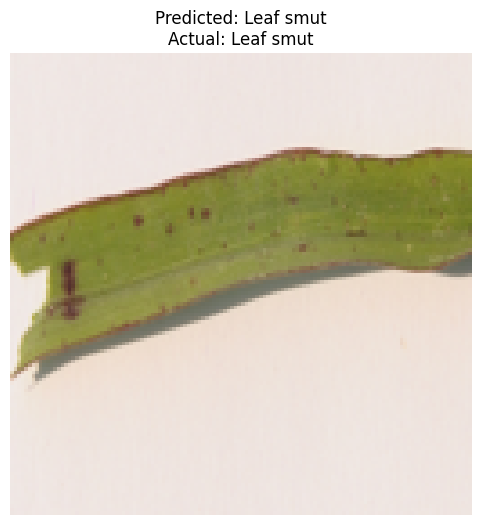

In [42]:
plt.figure(figsize=(6, 6))

plt.imshow(X_test[0])

plt.title(f"Predicted: {predicted_class}\n"
    f"Actual: {actual_class}")

plt.axis("off")
plt.show()

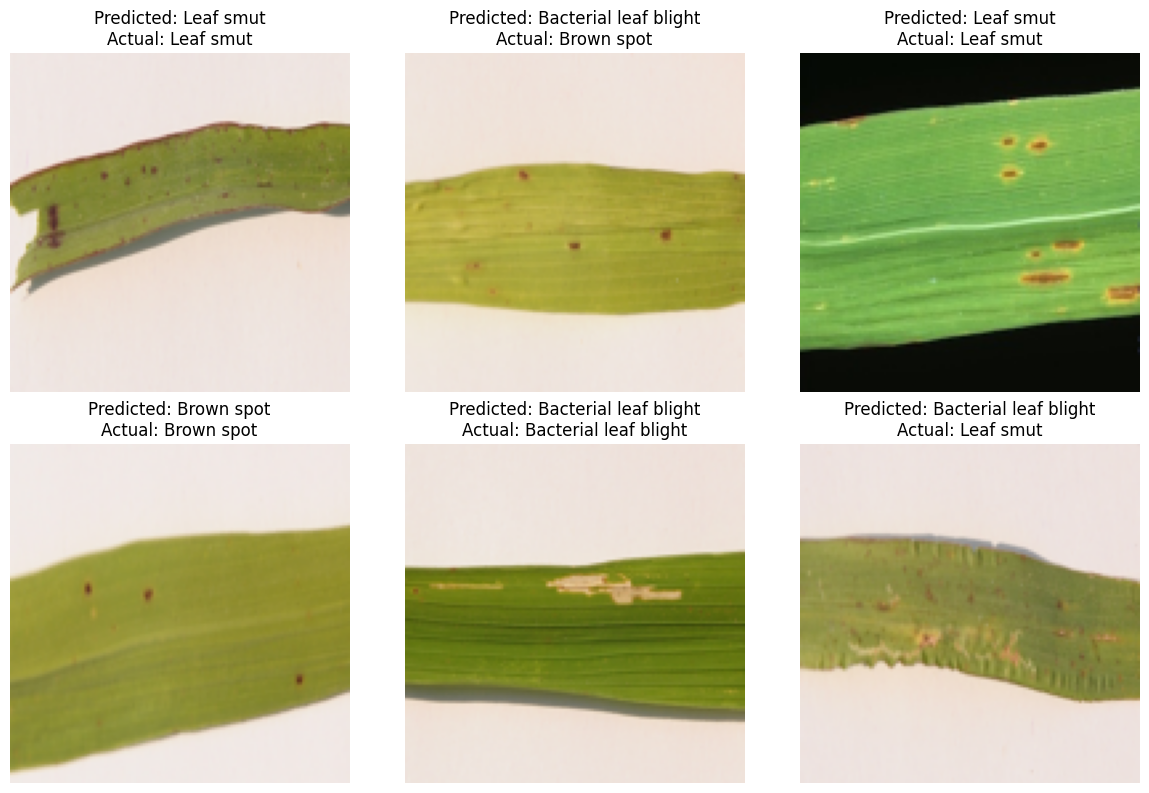

In [43]:
plt.figure(figsize=(12, 8))

for i in range(min(6, len(X_test))):
    prediction = loaded_model.predict(
        np.expand_dims(X_test[i], axis=0),
        verbose=0)

    predicted_index = np.argmax(prediction, axis=1)[0]

    predicted_name = loaded_label_encoder.inverse_transform([predicted_index])[0]

    actual_name = loaded_label_encoder.inverse_transform([y_test[i]])[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test[i])
    plt.title(f"Predicted: {predicted_name}\nActual: {actual_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
prediction_results = []

for i in range(len(X_test)):
    prediction = loaded_model.predict(np.expand_dims(X_test[i], axis=0),verbose=0)

    predicted_index = np.argmax(prediction, axis=1)[0]

    predicted_name = loaded_label_encoder.inverse_transform([predicted_index])[0]

    actual_name = loaded_label_encoder.inverse_transform([y_test[i]])[0]

    prediction_results.append({"Actual Disease": actual_name,"Predicted Disease": predicted_name})

prediction_df = pd.DataFrame(prediction_results)

display(prediction_df.head(10))

,Actual Disease,Predicted Disease
0,Leaf smut,Leaf smut
1,Brown spot,Bacterial leaf blight
2,Leaf smut,Leaf smut
3,Brown spot,Brown spot
4,Bacterial leaf blight,Bacterial leaf blight
5,Leaf smut,Bacterial leaf blight
6,Bacterial leaf blight,Bacterial leaf blight
7,Leaf smut,Bacterial leaf blight
8,Bacterial leaf blight,Bacterial leaf blight
9,Brown spot,Bacterial leaf blight


In [45]:
correct_predictions = (prediction_df["Actual Disease"]== prediction_df["Predicted Disease"]).sum()

total_predictions = len(prediction_df)

prediction_accuracy = correct_predictions / total_predictions

print("Correct Predictions:", correct_predictions)
print("Total Predictions:", total_predictions)
print("Prediction Accuracy:", prediction_accuracy)
print("Prediction Accuracy (%):", prediction_accuracy * 100)

Correct Predictions: 16
Total Predictions: 24
Prediction Accuracy: 0.6666666666666666
Prediction Accuracy (%): 66.66666666666666


In [46]:
prediction_df.to_csv("/content/rice_leaf_prediction_results.csv",index=False)

print("Prediction results saved successfully!")
print("File: /content/rice_leaf_prediction_results.csv")

Prediction results saved successfully!
File: /content/rice_leaf_prediction_results.csv


In [47]:
saved_predictions = pd.read_csv("/content/rice_leaf_prediction_results.csv")

print("Saved prediction file loaded successfully!")
print("Number of prediction records:", len(saved_predictions))

display(saved_predictions.head(10))

Saved prediction file loaded successfully!
Number of prediction records: 24


,Actual Disease,Predicted Disease
0,Leaf smut,Leaf smut
1,Brown spot,Bacterial leaf blight
2,Leaf smut,Leaf smut
3,Brown spot,Brown spot
4,Bacterial leaf blight,Bacterial leaf blight
5,Leaf smut,Bacterial leaf blight
6,Bacterial leaf blight,Bacterial leaf blight
7,Leaf smut,Bacterial leaf blight
8,Bacterial leaf blight,Bacterial leaf blight
9,Brown spot,Bacterial leaf blight


In [48]:
class_names = list(loaded_label_encoder.classes_)

with open("/content/rice_leaf_classes.txt", "w") as file:
    for class_name in class_names:
        file.write(class_name + "\n")

print("Class names saved successfully!")
print("Classes:", class_names)

Class names saved successfully!
Classes: [np.str_('Bacterial leaf blight'), np.str_('Brown spot'), np.str_('Leaf smut')]


In [49]:
print("===== CNN MODEL PERFORMANCE SUMMARY =====")

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("\nPrediction Accuracy:", prediction_accuracy)
print("Prediction Accuracy (%):", prediction_accuracy * 100)

print("\nNumber of Test Images:", len(X_test))
print("Number of Classes:", len(loaded_label_encoder.classes_))

print("\nDisease Classes:")
for class_name in loaded_label_encoder.classes_:
    print("-", class_name)

===== CNN MODEL PERFORMANCE SUMMARY =====
Test Accuracy: 0.6666666865348816
Test Loss: 0.6212787628173828

Prediction Accuracy: 0.6666666666666666
Prediction Accuracy (%): 66.66666666666666

Number of Test Images: 24
Number of Classes: 3

Disease Classes:
- Bacterial leaf blight
- Brown spot
- Leaf smut


In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True,zoom_range=0.2)

print("Data augmentation configured successfully!")

Data augmentation configured successfully!


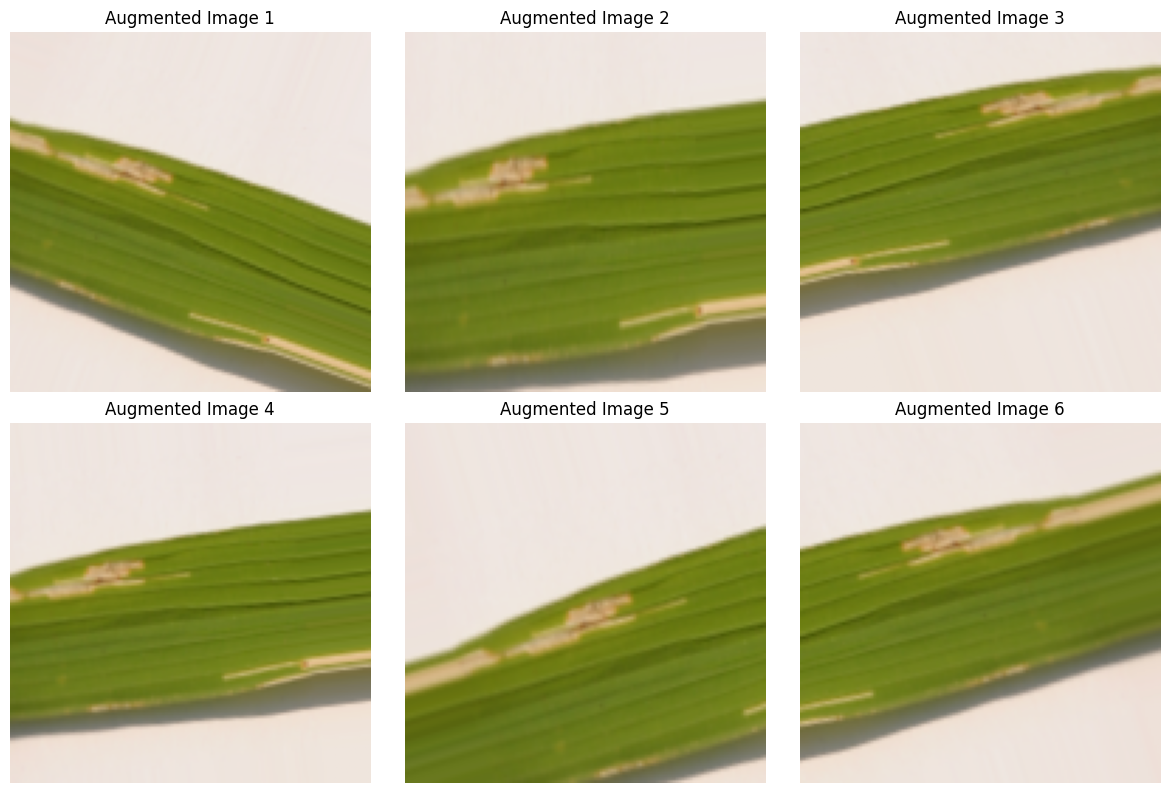

In [51]:
# Generate augmented images from one training image

sample_image = X_train[0]

# Add batch dimension
sample_image = np.expand_dims(sample_image, axis=0)

plt.figure(figsize=(12, 8))

for i, batch in enumerate(datagen.flow(sample_image, batch_size=1)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0])
    plt.title(f"Augmented Image {i + 1}")
    plt.axis("off")

    if i == 5:
        break

plt.tight_layout()
plt.show()

In [52]:
# Create augmented training data

augmented_images = []
augmented_labels = []

for i in range(len(X_train)):
    image = np.expand_dims(X_train[i], axis=0)

    # Generate one augmented image
    augmented_image = next(datagen.flow(image, batch_size=1, shuffle=False))[0]

    augmented_images.append(augmented_image)
    augmented_labels.append(y_train[i])

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Original training data shape:", X_train.shape)
print("Augmented training data shape:", augmented_images.shape)
print("Augmented labels shape:", augmented_labels.shape)

Original training data shape: (95, 128, 128, 3)
Augmented training data shape: (95, 128, 128, 3)
Augmented labels shape: (95,)


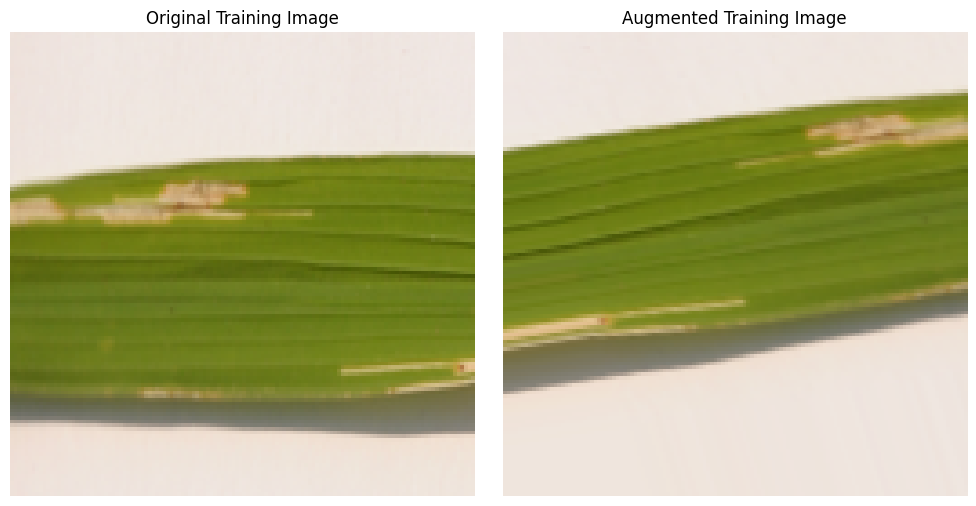

In [53]:
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(X_train[0])
plt.title("Original Training Image")
plt.axis("off")

# Augmented image
plt.subplot(1, 2, 2)
plt.imshow(augmented_images[0])
plt.title("Augmented Training Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [54]:
# Train CNN using augmented training data

augmented_model = Sequential([Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")])

augmented_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

augmented_history = augmented_model.fit(augmented_images,augmented_labels,epochs=20,batch_size=16,validation_split=0.2,verbose=1)

print("Augmented CNN training completed successfully!")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 563ms/step - accuracy: 0.3553 - loss: 1.1920 - val_accuracy: 0.4211 - val_loss: 1.0690
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 0.2763 - loss: 1.1124 - val_accuracy: 0.5263 - val_loss: 1.0923
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step - accuracy: 0.3947 - loss: 1.0976 - val_accuracy: 0.2105 - val_loss: 1.1110
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 0.5000 - loss: 1.0629 - val_accuracy: 0.5263 - val_loss: 1.0504
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.5000 - loss: 1.0542 - val_accuracy: 0.5789 - val_loss: 1.0014
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 584ms/step - accuracy: 0.4605 - loss: 1.0189 - val_accuracy: 0.5263 - val_loss: 1.0302
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 0.5789 - loss: 0.9996 - val_accuracy: 0.6842 - val_loss: 0.9836
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 427ms/step - accuracy: 0.5395 - loss: 0.8852 - val_accuracy: 0.4211 - val_loss: 1.0111
Epo

In [55]:
# Evaluate the augmented CNN model

aug_test_loss, aug_test_accuracy = augmented_model.evaluate(X_test,y_test,verbose=1)

print("===== AUGMENTED CNN PERFORMANCE =====")
print("Test Loss:", aug_test_loss)
print("Test Accuracy:", aug_test_accuracy)
print("Test Accuracy (%):", aug_test_accuracy * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.3750 - loss: 3.0059
===== AUGMENTED CNN PERFORMANCE =====
Test Loss: 3.0059337615966797
Test Accuracy: 0.375
Test Accuracy (%): 37.5


In [56]:
# Compare baseline CNN and augmented CNN

comparison_data = {"Model": ["Baseline CNN","Augmented CNN"],"Test Accuracy": [test_accuracy,aug_test_accuracy],"Test Loss": [test_loss,aug_test_loss]}

model_comparison = pd.DataFrame(comparison_data)

print("===== MODEL PERFORMANCE COMPARISON =====")
display(model_comparison)

===== MODEL PERFORMANCE COMPARISON =====


,Model,Test Accuracy,Test Loss
0,Baseline CNN,0.666667,0.621279
1,Augmented CNN,0.375000,3.005934


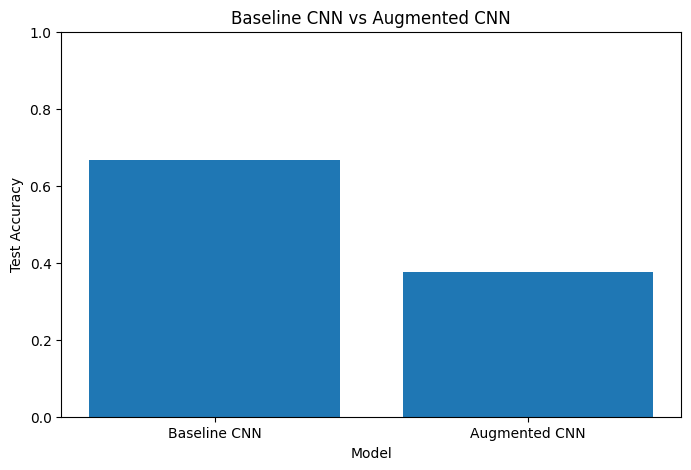

In [57]:
# Visualize model accuracy comparison

plt.figure(figsize=(8, 5))

plt.bar(model_comparison["Model"],model_comparison["Test Accuracy"])

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Baseline CNN vs Augmented CNN")
plt.ylim(0, 1)

plt.show()

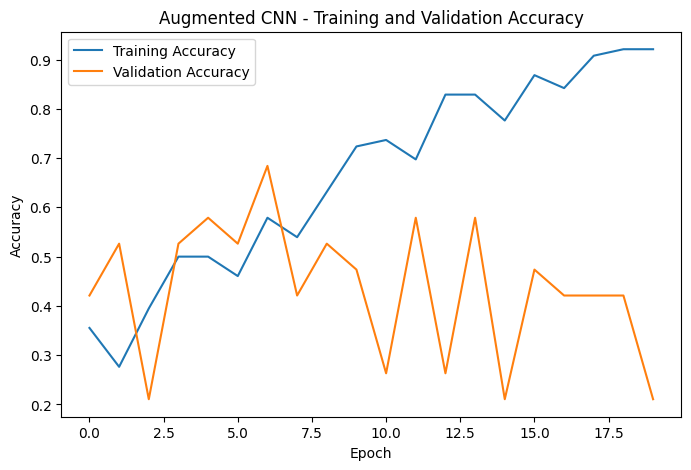

In [58]:
# Plot augmented CNN training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(augmented_history.history["accuracy"],label="Training Accuracy")

plt.plot(augmented_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Augmented CNN - Training and Validation Accuracy")
plt.legend()
plt.show()

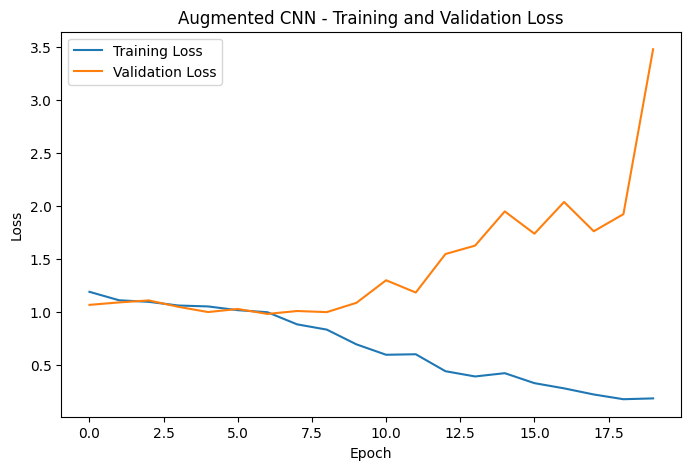

In [59]:
# Plot augmented CNN training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(augmented_history.history["loss"],label="Training Loss")

plt.plot(augmented_history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmented CNN - Training and Validation Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


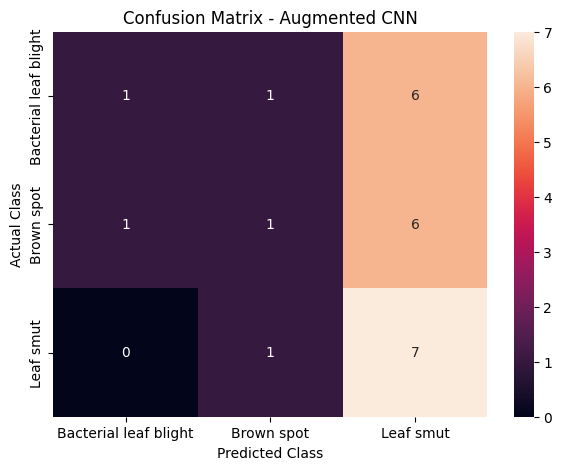

In [60]:
# Confusion Matrix for Augmented CNN

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate predictions using the augmented model
aug_y_pred_prob = augmented_model.predict(X_test)
aug_y_pred = np.argmax(aug_y_pred_prob, axis=1)

# Calculate confusion matrix
aug_cm = confusion_matrix(y_test, aug_y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(aug_cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Augmented CNN")

plt.show()

In [61]:
# Classification Report for Augmented CNN

from sklearn.metrics import classification_report

aug_report = classification_report(y_test,aug_y_pred,target_names=label_encoder.classes_)

print("Classification Report - Augmented CNN")
print(aug_report)

Classification Report - Augmented CNN
                       precision    recall  f1-score   support

Bacterial leaf blight       0.50      0.12      0.20         8
           Brown spot       0.33      0.12      0.18         8
            Leaf smut       0.37      0.88      0.52         8

             accuracy                           0.38        24
            macro avg       0.40      0.38      0.30        24
         weighted avg       0.40      0.38      0.30        24



In [62]:
# Compare Original CNN and Augmented CNN Accuracy

print("Original CNN Accuracy:")
print(f"{test_accuracy * 100:.2f}%")

print("\nAugmented CNN Accuracy:")
print(f"{aug_test_accuracy * 100:.2f}%")

if aug_test_accuracy > test_accuracy:
    print("\nAugmented CNN performs better than Original CNN.")
elif aug_test_accuracy < test_accuracy:
    print("\nOriginal CNN performs better than Augmented CNN.")
else:
    print("\nBoth models have the same accuracy.")

Original CNN Accuracy:
66.67%

Augmented CNN Accuracy:
37.50%

Original CNN performs better than Augmented CNN.


In [63]:
# Classification performance comparison

baseline_report = classification_report(y_test,y_pred,target_names=label_encoder.classes_,output_dict=True)

augmented_report = classification_report(y_test,aug_y_pred,target_names=label_encoder.classes_,output_dict=True)

performance_comparison = pd.DataFrame({"Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score"],
    "Baseline CNN": [
        baseline_report["accuracy"],
        baseline_report["macro avg"]["precision"],
        baseline_report["macro avg"]["recall"],
        baseline_report["macro avg"]["f1-score"]],
    "Augmented CNN": [
        augmented_report["accuracy"],
        augmented_report["macro avg"]["precision"],
        augmented_report["macro avg"]["recall"],
        augmented_report["macro avg"]["f1-score"]]})

print("===== CLASSIFICATION PERFORMANCE COMPARISON =====")
display(performance_comparison)

===== CLASSIFICATION PERFORMANCE COMPARISON =====


,Metric,Baseline CNN,Augmented CNN
0,Accuracy,0.666667,0.375000
1,Macro Precision,0.762821,0.400585
2,Macro Recall,0.666667,0.375000
3,Macro F1-Score,0.654040,0.300112


In [64]:
# Save Augmented CNN model

augmented_model.save("/content/rice_leaf_augmented_cnn.h5")

print("Augmented CNN model saved successfully!")
print("File: /content/rice_leaf_augmented_cnn.h5")

Augmented CNN model saved successfully!
File: /content/rice_leaf_augmented_cnn.h5


In [65]:
# Identify the better performing model

if aug_test_accuracy > test_accuracy:
    best_model = "Augmented CNN"
    best_accuracy = aug_test_accuracy
elif test_accuracy > aug_test_accuracy:
    best_model = "Baseline CNN"
    best_accuracy = test_accuracy
else:
    best_model = "Both models have the same accuracy"
    best_accuracy = test_accuracy

print("===== BEST MODEL =====")
print("Best Model:", best_model)
print("Best Test Accuracy:", best_accuracy)
print("Best Test Accuracy (%):", best_accuracy * 100)

===== BEST MODEL =====
Best Model: Baseline CNN
Best Test Accuracy: 0.6666666865348816
Best Test Accuracy (%): 66.66666865348816


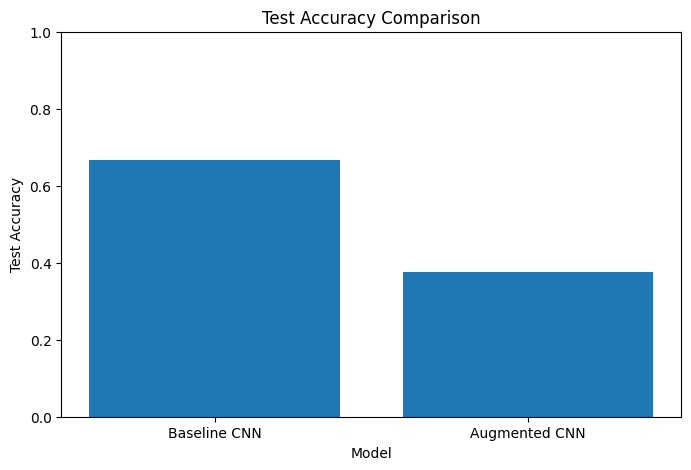

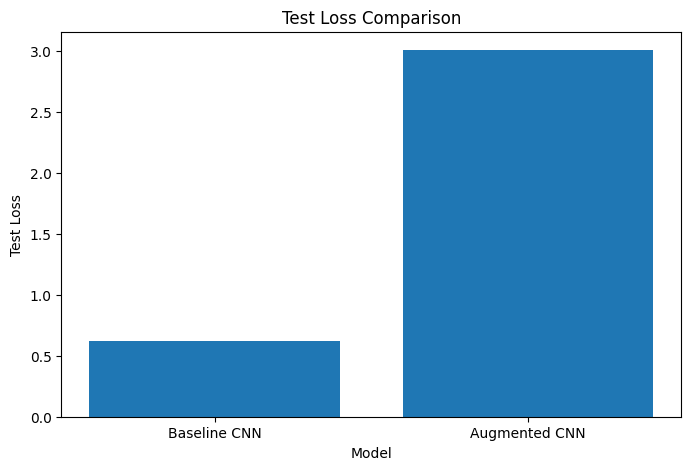

In [66]:
# Final Model Comparison Chart

models = ["Baseline CNN", "Augmented CNN"]

accuracies = [test_accuracy,aug_test_accuracy]

losses = [test_loss,aug_test_loss]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

plt.figure(figsize=(8, 5))

plt.bar(models, losses)

plt.xlabel("Model")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")

plt.show()

In [67]:
# Final Model Comparison Table

final_comparison = pd.DataFrame({
    "Model": ["Baseline CNN","Augmented CNN"],
    "Test Accuracy (%)": [test_accuracy * 100,aug_test_accuracy * 100],
    "Test Loss": [test_loss,aug_test_loss]})

print("===== FINAL MODEL COMPARISON =====")
display(final_comparison)

===== FINAL MODEL COMPARISON =====


,Model,Test Accuracy (%),Test Loss
0,Baseline CNN,66.666669,0.621279
1,Augmented CNN,37.500000,3.005934


In [68]:
# Analyze the effect of Data Augmentation

accuracy_difference = (aug_test_accuracy - test_accuracy) * 100

loss_difference = aug_test_loss - test_loss

print("===== DATA AUGMENTATION ANALYSIS =====")

print("Baseline CNN Accuracy:",test_accuracy * 100, "%")

print("Augmented CNN Accuracy:",aug_test_accuracy * 100, "%")

print("\nAccuracy Difference:",accuracy_difference, "%")

print("Baseline CNN Loss:",test_loss)

print("Augmented CNN Loss:",aug_test_loss)

print("\nLoss Difference:",loss_difference)

if accuracy_difference > 0:
    print("\nConclusion: Data augmentation improved test accuracy.")
elif accuracy_difference < 0:
    print("\nConclusion: Data augmentation reduced test accuracy.")
else:
    print("\nConclusion: Data augmentation produced the same test accuracy.")

===== DATA AUGMENTATION ANALYSIS =====
Baseline CNN Accuracy: 66.66666865348816 %
Augmented CNN Accuracy: 37.5 %

Accuracy Difference: -29.16666865348816 %
Baseline CNN Loss: 0.6212787628173828
Augmented CNN Loss: 3.0059337615966797

Loss Difference: 2.384654998779297

Conclusion: Data augmentation reduced test accuracy.


In [69]:
# Create prediction results for Augmented CNN

aug_prediction_results = []

for i in range(len(X_test)):
    predicted_index = aug_y_pred[i]

    predicted_name = loaded_label_encoder.inverse_transform([predicted_index])[0]

    actual_name = loaded_label_encoder.inverse_transform([y_test[i]])[0]

    aug_prediction_results.append({"Actual Disease": actual_name,"Predicted Disease": predicted_name})

aug_prediction_df = pd.DataFrame(aug_prediction_results)

print("===== AUGMENTED CNN PREDICTION RESULTS =====")
display(aug_prediction_df.head(10))

print("\nTotal Test Predictions:",
      len(aug_prediction_df))

===== AUGMENTED CNN PREDICTION RESULTS =====


,Actual Disease,Predicted Disease
0,Leaf smut,Leaf smut
1,Brown spot,Leaf smut
2,Leaf smut,Leaf smut
3,Brown spot,Leaf smut
4,Bacterial leaf blight,Leaf smut
5,Leaf smut,Brown spot
6,Bacterial leaf blight,Leaf smut
7,Leaf smut,Leaf smut
8,Bacterial leaf blight,Leaf smut
9,Brown spot,Leaf smut



Total Test Predictions: 24


In [70]:
# Save Augmented CNN prediction results

aug_prediction_df.to_csv("/content/rice_leaf_augmented_prediction_results.csv",index=False)

print("Augmented prediction results saved successfully!")
print("File: /content/rice_leaf_augmented_prediction_results.csv")

Augmented prediction results saved successfully!
File: /content/rice_leaf_augmented_prediction_results.csv


In [71]:
# Verify Augmented CNN prediction results

saved_aug_predictions = pd.read_csv("/content/rice_leaf_augmented_prediction_results.csv")

print("Augmented prediction file loaded successfully!")
print("Number of prediction records:",len(saved_aug_predictions))

display(saved_aug_predictions.head(10))

Augmented prediction file loaded successfully!
Number of prediction records: 24


,Actual Disease,Predicted Disease
0,Leaf smut,Leaf smut
1,Brown spot,Leaf smut
2,Leaf smut,Leaf smut
3,Brown spot,Leaf smut
4,Bacterial leaf blight,Leaf smut
5,Leaf smut,Brown spot
6,Bacterial leaf blight,Leaf smut
7,Leaf smut,Leaf smut
8,Bacterial leaf blight,Leaf smut
9,Brown spot,Leaf smut


In [72]:
# Calculate Augmented CNN prediction accuracy

aug_correct_predictions = (aug_prediction_df["Actual Disease"]
    == aug_prediction_df["Predicted Disease"]).sum()

aug_total_predictions = len(aug_prediction_df)

aug_prediction_accuracy = (aug_correct_predictions / aug_total_predictions)

print("===== AUGMENTED CNN PREDICTION ACCURACY =====")

print("Correct Predictions:",
      aug_correct_predictions)

print("Total Predictions:",
      aug_total_predictions)

print("Prediction Accuracy:",
      aug_prediction_accuracy)

print("Prediction Accuracy (%):",
      aug_prediction_accuracy * 100)

===== AUGMENTED CNN PREDICTION ACCURACY =====
Correct Predictions: 9
Total Predictions: 24
Prediction Accuracy: 0.375
Prediction Accuracy (%): 37.5


In [73]:
# Final Project Conclusion

print("===== FINAL PROJECT CONCLUSION =====")

print("\nProject Name:")
print("Rice Leaf Disease Detection using CNN and Data Augmentation")

print("\nTechniques Used:")
print("- Image Preprocessing")
print("- Label Encoding")
print("- CNN Model")
print("- Data Augmentation")
print("- Model Evaluation")

print("\nBest Model:")
print(best_model)

print("Best Accuracy (%):")
print(best_accuracy * 100)

print("\nFinal Conclusion:")

if best_model == "Augmented CNN":
    print("The Augmented CNN model achieved the best performance""and improved the ability to classify rice leaf diseases.")
elif best_model == "Baseline CNN":
    print("The Baseline CNN model achieved the best performance""for this dataset.")
else:
    print("Both models achieved similar performance.")

===== FINAL PROJECT CONCLUSION =====

Project Name:
Rice Leaf Disease Detection using CNN and Data Augmentation

Techniques Used:
- Image Preprocessing
- Label Encoding
- CNN Model
- Data Augmentation
- Model Evaluation

Best Model:
Baseline CNN
Best Accuracy (%):
66.66666865348816

Final Conclusion:
The Baseline CNN model achieved the best performancefor this dataset.


In [74]:
# Final Results Table

final_results = pd.DataFrame({
    "Model": ["Baseline CNN","Augmented CNN"],
    "Test Accuracy (%)": [test_accuracy * 100,aug_test_accuracy * 100],
    "Test Loss": [test_loss,aug_test_loss]})

print("===== FINAL MODEL RESULTS =====")
display(final_results)

===== FINAL MODEL RESULTS =====


,Model,Test Accuracy (%),Test Loss
0,Baseline CNN,66.666669,0.621279
1,Augmented CNN,37.500000,3.005934


In [75]:
# Save Final Results Table

final_results.to_csv("/content/rice_leaf_final_results.csv",index=False)

print("Final results table saved successfully!")
print("File: /content/rice_leaf_final_results.csv")

Final results table saved successfully!
File: /content/rice_leaf_final_results.csv


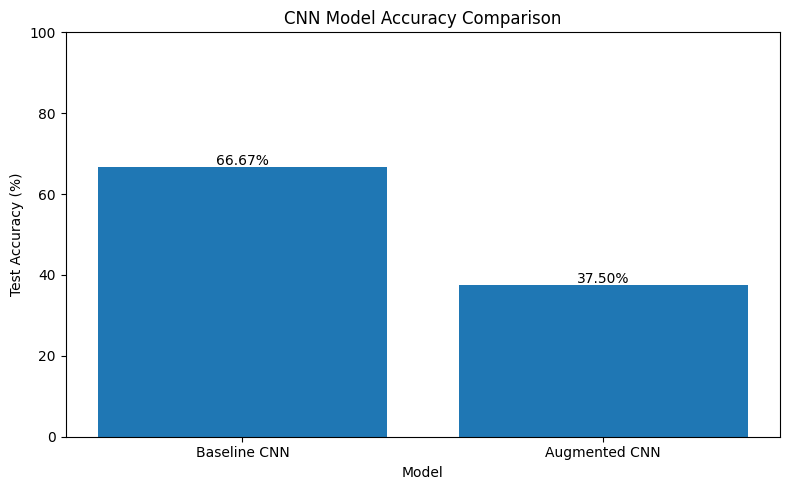

In [76]:
# Final Model Accuracy Comparison

import matplotlib.pyplot as plt

models = ["Baseline CNN", "Augmented CNN"]
accuracies = [test_accuracy * 100,aug_test_accuracy * 100]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.title("CNN Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [77]:
# Save the best CNN model

if best_model == "Augmented CNN":
    final_model = augmented_model
else:
    final_model = model

final_model.save("/content/rice_leaf_disease_cnn_model.keras")

print("Final CNN model saved successfully!")
print("File: /content/rice_leaf_disease_cnn_model.keras")

Final CNN model saved successfully!
File: /content/rice_leaf_disease_cnn_model.keras


In [78]:
# Save class labels

import json

class_labels = label_encoder.classes_.tolist()

with open("/content/rice_leaf_class_labels.json", "w") as f:
    json.dump(class_labels, f, indent=4)

print("Class labels saved successfully!")
print("File: /content/rice_leaf_class_labels.json")
print("Classes:", class_labels)

Class labels saved successfully!
File: /content/rice_leaf_class_labels.json
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [79]:
# Final Project Files Check

import os

files_to_check = [
    "/content/rice_leaf_disease_cnn_model.keras",
    "/content/rice_leaf_class_labels.json",
    "/content/rice_leaf_final_results.csv",
    "/content/rice_leaf_augmented_prediction_results.csv"]

print("===== FINAL PROJECT FILES =====")

for file_path in files_to_check:
    if os.path.exists(file_path):
        print("✓", os.path.basename(file_path))
    else:
        print("✗", os.path.basename(file_path), "- Not Found")

===== FINAL PROJECT FILES =====
✓ rice_leaf_disease_cnn_model.keras
✓ rice_leaf_class_labels.json
✓ rice_leaf_final_results.csv
✓ rice_leaf_augmented_prediction_results.csv
